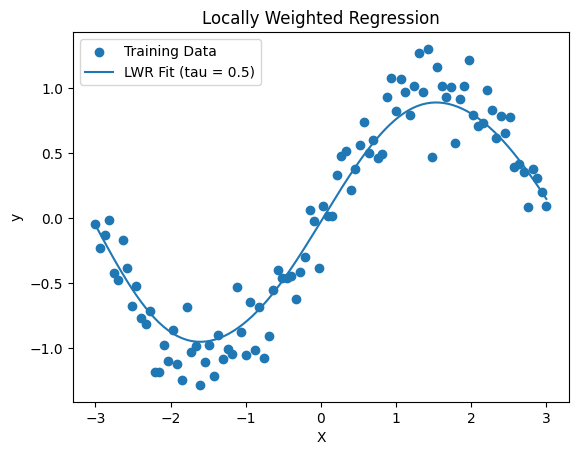

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def gaussian_kernel(x, x_query, tau):
    return np.exp(-np.square(x - x_query) / (2 * tau ** 2))
def locally_weighted_regression(X, y, x_query, tau):
    """Perform Locally Weighted Regression at a query point."""
    m = X.shape[0]
    # Add bias term
    X_bias = np.c_[np.ones(m), X]
    x_query_bias = np.array([1, x_query])
    # Compute weights using Gaussian kernel
    W = np.diag(gaussian_kernel(X, x_query, tau))
    # Weighted least squares
    theta = np.linalg.pinv(X_bias.T @ W @ X_bias) @ (X_bias.T @ W @ y)
    # Prediction
    return x_query_bias @ theta

# Generate synthetic dataset
np.random.seed(42)
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(0, 0.2, X.shape)

# Fit LWR model
tau = 0.5
X_test = np.linspace(-3, 3, 200)
y_pred = np.array([
    locally_weighted_regression(X, y, x, tau) for x in X_test
])

# Plot results
plt.scatter(X, y, label="Training Data")
plt.plot(X_test, y_pred, label="LWR Fit (tau = 0.5)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Locally Weighted Regression")
plt.legend()
plt.show()